<a href="https://colab.research.google.com/github/Kinds-of-Intelligence-CFI/measurement-layouts/blob/main/basic_measurement_layout/basic_measurement_layout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Basic Measurement Layout

In [1]:
!pip install pymc --quiet
!pip install arviz --quiet

In [2]:
import arviz as az
import graphviz
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import random as rm
import requests
import seaborn as sns

from io import StringIO
from collections import defaultdict
from IPython.display import Image
from scipy import stats
from sklearn.metrics import roc_auc_score, brier_score_loss, average_precision_score, f1_score
from sklearn.model_selection import train_test_split
from pymc import model

print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v5.24.0


In [3]:
# Base URL for raw GitHub files
base_url = "https://raw.githubusercontent.com/Kinds-of-Intelligence-CFI/measurement-layouts/refs/heads/main/basic_measurement_layout/data/"

# Pixels and noise levels
pixel_sizes = range(4, 44, 4)
noise_levels = range(0, 10)

# Read and combine
dataframes = []
for p in pixel_sizes:
  for n in noise_levels:
    url = base_url + f"results_pixels_{p}_noise_0.{n}.csv"
    response = requests.get(url)
    df = pd.read_csv(StringIO(response.text))
    dataframes.append(df)

# Combine all DataFrames
combined_df = pd.concat(dataframes, ignore_index=True)

In [4]:
def logistic_general(x, min, max, c = 0, p = 0.99):

  """
  Generalized version of the logistic where min can be any number, not just 0 as above.

  :param min: The min ability/demand
  :param max: The max ability/demand
  :param c: Set different from 0 when we are dealing with multiple choice responses; e.g. c is 0.5 when the response is yes/no, and c is 0.25 if there are 4 possible choices
  :param p: The probability we want to set the max margin to (e.g. 0.99 or 0.999); the min margin will be set to 1 - p
  :param k: The slope of the logistic
  """
  max_n = max - min
  k = - np.log((1 - p )/(p - c)) / max_n
  return c + ((1 - c) / (1 + np.exp(-k * x)))

def brierDecomp(preds, outs):

  brier= 1/len(preds) * sum( (preds-outs)**2 )
  ## bin predictions
  bins = np.linspace(0,1,11)
  binCenters = (bins[:-1] +bins[1:]) /2
  binPredInds = np.digitize(preds,binCenters)
  binnedPreds = bins[binPredInds]

  binTrueFreqs = np.zeros(10)
  binPredFreqs = np.zeros(10)
  binCounts = np.zeros(10)

  for i in range(10):
      idx = (preds >= bins[i]) & (preds < bins[i+1])

      binTrueFreqs[i] = np.sum(outs[idx])/np.sum(idx) if np.sum(idx) > 0 else 0
     # print(np.sum(outs[idx]), np.sum(idx), binTrueFreqs[i])
      binPredFreqs[i] = np.mean(preds[idx]) if np.sum(idx) > 0 else 0
      binCounts[i] = np.sum(idx)

  calibration = np.sum(binCounts * (binTrueFreqs - binPredFreqs) ** 2) / np.sum(binCounts) if np.sum(binCounts) > 0 else 0
  refinement = np.sum(binCounts * (binTrueFreqs *(1 - binTrueFreqs))) / np.sum(binCounts) if np.sum(binCounts) > 0 else 0
  # Compute refinement component
  #refinement = brier - calibration
  return brier, calibration, refinement

def predict(m, trace, relevantData):
  with m:
    predictions = pm.sample_posterior_predictive(trace, var_names=["successP"], return_inferencedata=False, predictions=True, extend_inferencedata=False)
    predictionSuccessChainRuns = predictions["successP"][:,:,0:len(relevantData)]
    predictionsSuccessInstance = np.mean(predictionSuccessChainRuns, (0,1))
    successes = np.array([0 if val < -0.99 else 1 for val in relevantData['finalReward']])

    return predictionsSuccessInstance, successes

In [5]:
def setupModel(data):
  successes = [0 if val < -0.99 else 1 for val in data['finalReward']]

  abilityMin = {}
  abilityMax = {}

  abilityMin["navAbility"] = 0
  abilityMax["navAbility"] = data['distance'].max()

  abilityMin["visualAcuity"] = 0.0001
  abilityMax["visualAcuity"] = (data['distance']/data['size']).min()

  m = pm.Model()
  with m:
    navAbility = pm.HalfNormal("navAbility", sigma = abilityMax["navAbility"]/2)
    visualAcuity = pm.HalfNormal("visualAcuity", sigma = abilityMax["visualAcuity"]/2)

    goalDist = pm.Data("goalDistance", data["distance"])
    goalSize = pm.Data("goalSize", data["size"])

    navP = pm.Deterministic("navP", logistic_general(navAbility - goalDist, min = abilityMin["navAbility"], max = abilityMax["navAbility"], c = 0, p = 0.99))
    visualP = pm.Deterministic("visualP", logistic_general(np.log(visualAcuity) - np.log(goalDist/goalSize), min = np.log(abilityMin["visualAcuity"]), max = np.log(abilityMax["visualAcuity"]), c = 0, p = 0.99))

    successP = pm.Deterministic("successP", navP * visualP)
    # successP = pm.Deterministic("successP", (navP + visualP)/2) # compensatory relationship

    taskSuccess = pm.Bernoulli("taskSuccess", successP, observed = successes)

  return m, abilityMin, abilityMax, successes

In [ ]:
data = combined_df[(combined_df['pixelInput'] == 4) & (combined_df['navigationNoise'] == 0.0)]
m, abilityMin, abilityMax, successes = setupModel(data=data)
gv = pm.model_graph.model_to_graphviz(m)
gv

In [6]:
pymc_sample_num = 2000

chains = 4

In [ ]:
results = defaultdict(list)
visual_acuity_list = []
nav_ability_list = []

for p in pixel_sizes:
  for n in noise_levels:
    print(f"Fitting measurement layout for agent with {p}x{p} input and 0.{n} navigation noise.")
    results['pixels'].append(p)
    results['noise'].append(n/10)

    data = combined_df[(combined_df['pixelInput'] == p) & (combined_df['navigationNoise'] == n/10)]
    train_set, test_set = train_test_split(data, test_size = 0.2, random_state = 2024)

    model_train, _, _, _ = setupModel(data=train_set)

    with model_train:
      data_training = pm.sample(pymc_sample_num, target_accept=0.95, chains = chains)

    model_test, _, _, _ = setupModel(data=test_set)

    predictionsSuccessInstance, successes = predict(model_test, data_training, test_set)

    agentBrierScoreSuccess, agentCalibrationSuccess, agentRefinementSuccess = brierDecomp(predictionsSuccessInstance, successes)
    agentAggBrierScoreSuccess, agentAggCalibrationSuccess, agentAggRefinementSuccess = brierDecomp(np.repeat(np.mean(successes), len(successes)), successes)

    results['modelBrier'].append(agentBrierScoreSuccess)
    results['aggBrier'].append(agentAggBrierScoreSuccess)
    results['modelBetter'].append(agentBrierScoreSuccess < agentAggBrierScoreSuccess)
    results['modelCalibration'].append(agentCalibrationSuccess)
    results['aggCalibration'].append(agentAggCalibrationSuccess)
    results['modelRefinement'].append(agentRefinementSuccess)
    results['aggRefinement'].append(agentAggRefinementSuccess)
    results['meanSuccessTest'].append(np.mean(successes))

    model_all, abilityMin, abilityMax, successes = setupModel(data=data)

    with model_train:
      data_all = pm.sample(pymc_sample_num, target_accept=0.95, chains = chains)

    visual_acuity_list.append(data_all['posterior']['visualAcuity'])
    nav_ability_list.append(data_all['posterior']['navAbility'])

    navMean = float(np.mean(data_all['posterior']['navAbility']))
    navStd = float(np.std(data_all['posterior']['navAbility']))
    visualMean = float(np.mean(data_all['posterior']['visualAcuity']))
    visualStd = float(np.std(data_all['posterior']['visualAcuity']))

    results['navigationMean'].append(navMean)
    results['navigationStd'].append(navStd)
    results['visualAcuityMean'].append(visualMean)
    results['visualAcuityStd'].append(visualStd)

    results['meanSuccessAll'].append(np.mean(successes))

results_df = pd.DataFrame(results)

In [10]:
results_df

,pixels,noise,modelBrier,aggBrier,modelBetter,modelCalibration,aggCalibration,modelRefinement,aggRefinement,meanSuccessTest,navigationMean,navigationStd,visualAcuityMean,visualAcuityStd,meanSuccessAll
0,4,0.0,0.021418,0.024375,True,0.000248,0.000000e+00,0.024375,0.024375,0.025,3.232676,3.159767,0.060918,0.064925,0.010
1,4,0.1,0.021435,0.024375,True,0.000250,0.000000e+00,0.024375,0.024375,0.025,3.324032,3.322653,0.061056,0.062427,0.010
2,4,0.2,0.021396,0.024375,True,0.000246,0.000000e+00,0.024375,0.024375,0.025,3.342157,3.244638,0.058093,0.059177,0.010
3,4,0.3,0.021454,0.024375,True,0.000252,0.000000e+00,0.024375,0.024375,0.025,3.237131,3.315352,0.061419,0.064871,0.010
4,4,0.4,0.021434,0.024375,True,0.000249,0.000000e+00,0.024375,0.024375,0.025,3.320312,3.462753,0.062113,0.064125,0.010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,40,0.5,0.198765,0.247500,True,0.106045,1.232595e-32,0.096477,0.247500,0.450,55.056030,6.429843,5.288832,0.426270,0.469
96,40,0.6,0.198856,0.247500,True,0.106141,1.232595e-32,0.096477,0.247500,0.450,55.130294,6.418719,5.296255,0.440502,0.469
97,40,0.7,0.199075,0.247500,True,0.108363,1.232595e-32,0.094179,0.247500,0.450,54.062583,6.016940,5.270254,0.438839,0.466
98,40,0.8,0.183989,0.240000,True,0.104314,0.000000e+00,0.085413,0.240000,0.400,35.804362,1.999243,4.953646,0.462622,0.393


In [22]:
visual_acuity_list_subset = [visual_acuity_list[0], visual_acuity_list[8],visual_acuity_list[50], visual_acuity_list[58], visual_acuity_list[90], visual_acuity_list[98]]

array([<Axes: title={'center': '95.0% HDI'}>], dtype=object)

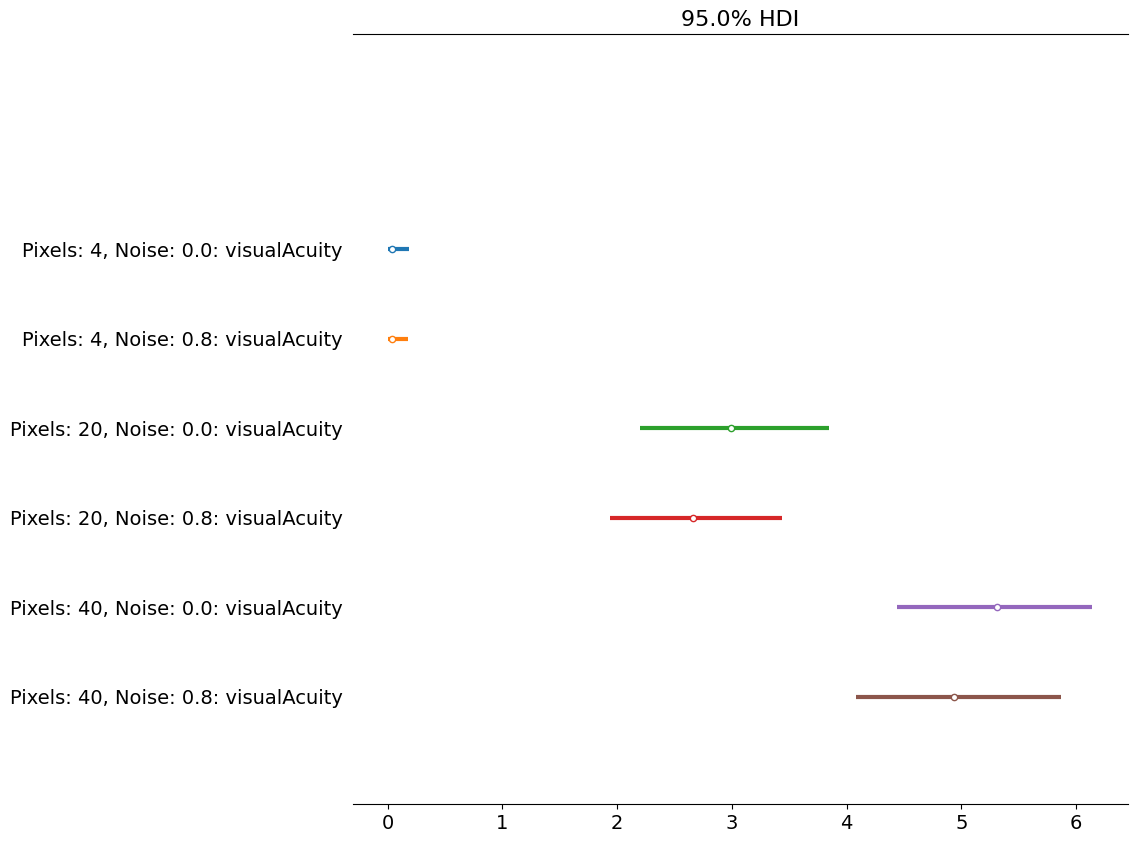

In [24]:
az.plot_forest(visual_acuity_list_subset,
               model_names=["Pixels: 4, Noise: 0.0", "Pixels: 4, Noise: 0.8", "Pixels: 20, Noise: 0.0", "Pixels: 20, Noise: 0.8", "Pixels: 40, Noise: 0.0", "Pixels: 40, Noise: 0.8"],
               var_names='visualAcuity',
                combined=True,
                hdi_prob=0.95,
                quartiles=False,
                legend=False,
                figsize=(10,10),
                # colors = colours_all,
               )

In [59]:
nav_ability_list_subset = [nav_ability_list[70], nav_ability_list[73], nav_ability_list[78], nav_ability_list[79], nav_ability_list[90], nav_ability_list[93], nav_ability_list[98], nav_ability_list[99]]

array([<Axes: title={'center': '95.0% HDI'}>], dtype=object)

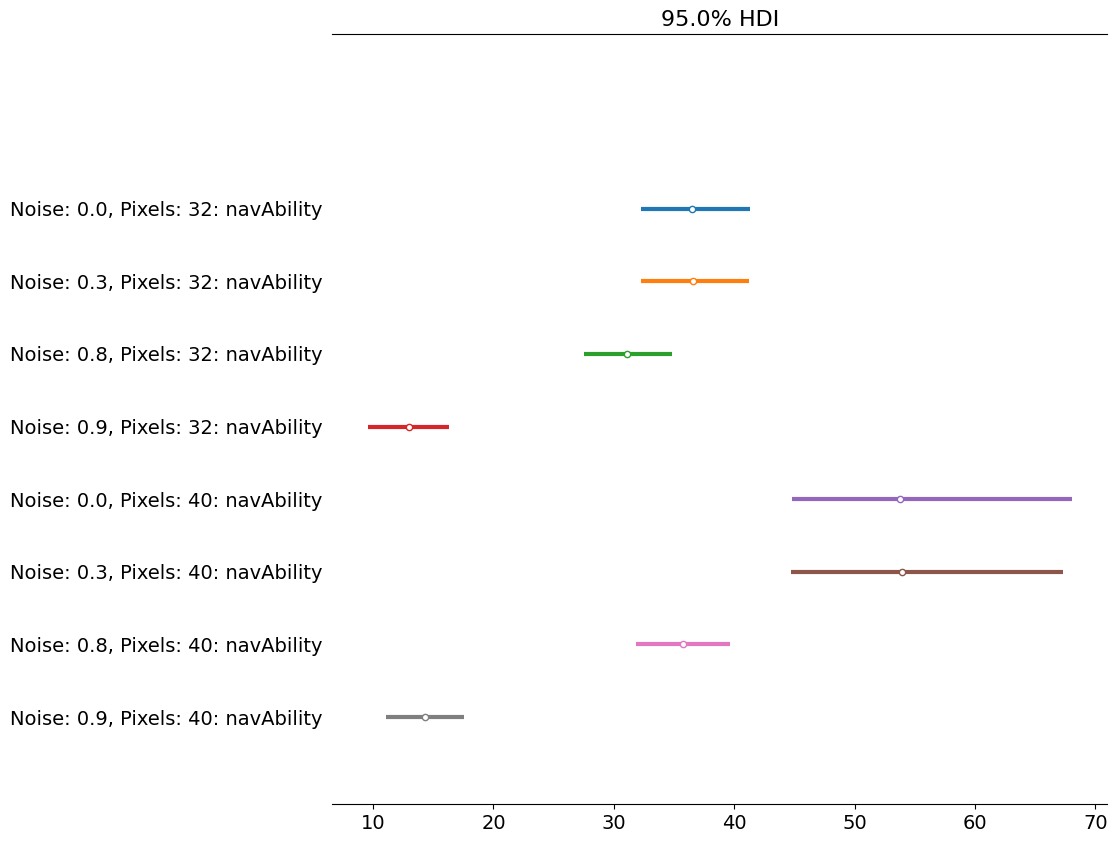

In [60]:
az.plot_forest(nav_ability_list_subset,
               model_names=["Noise: 0.0, Pixels: 32", "Noise: 0.3, Pixels: 32", "Noise: 0.8, Pixels: 32", "Noise: 0.9, Pixels: 32", "Noise: 0.0, Pixels: 40", "Noise: 0.3, Pixels: 40", "Noise: 0.8, Pixels: 40", "Noise: 0.9, Pixels: 40"],
               var_names='navAbility',
                combined=True,
                hdi_prob=0.95,
                quartiles=False,
                legend=False,
                figsize=(10,10),
                # colors = colours_all,
               )